# Game AI Agent Comparison

This notebook compares four game-playing agents using win rate and decision time.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

print("Hello, Playful Tech!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Python executable: {sys.executable}")

Hello, Playful Tech!
Python version: 3.12.14
Python executable: E:\python-notebook-practice\game-ai-agent-comparison\.venv\Scripts\python.exe


In [2]:
data_file = Path("../data/agent_playtests.csv")
results = pd.read_csv(data_file)

if len(results) != 4:
    raise ValueError("Expected playtest data for exactly four agents.")

results

,agent,win_rate,decision_time_ms
0,Random Bot,0.30,1
1,Rule-Based Bot,0.58,3
2,Neural Agent A,0.81,28
3,Neural Agent B,0.78,8


In [3]:
results["fitness_score"] = (
    results["win_rate"] * 100
    - results["decision_time_ms"] * 0.5
)

results[
    ["agent", "win_rate", "decision_time_ms", "fitness_score"]
]

,agent,win_rate,decision_time_ms,fitness_score
0,Random Bot,0.30,1,29.5
1,Rule-Based Bot,0.58,3,56.5
2,Neural Agent A,0.81,28,67.0
3,Neural Agent B,0.78,8,74.0


In [4]:
best_agent = results.loc[results["fitness_score"].idxmax()]

print(f"Recommended agent: {best_agent['agent']}")
print(f"Win rate: {best_agent['win_rate']:.0%}")
print(
    "Average decision time: "
    f"{best_agent['decision_time_ms']:.0f} ms"
)
print(f"Fitness score: {best_agent['fitness_score']:.1f}")

Recommended agent: Neural Agent B
Win rate: 78%
Average decision time: 8 ms
Fitness score: 74.0


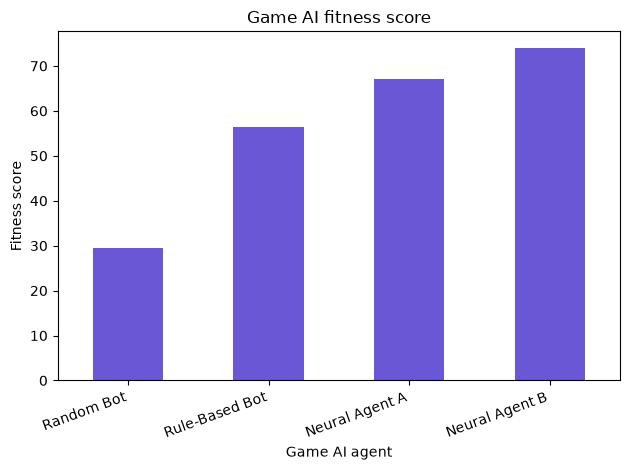

In [5]:
axis = results.plot(
    x="agent",
    y="fitness_score",
    kind="bar",
    legend=False,
    color="#6957d5",
    title="Game AI fitness score",
)

axis.set_xlabel("Game AI agent")
axis.set_ylabel("Fitness score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()